In [1]:
import pandas as pd

df = pd.read_excel("../data/dataset.xlsx")

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [3]:
df

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


In [ ]:
# Import libraries
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df["body"]
y = df["rating"]


# -----------------------------
# 3. Train-Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# -----------------------------
# 4. Create ML Pipeline
# -----------------------------

model = Pipeline([
    
    # Convert text to numerical vectors
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=20000,
        ngram_range=(1,2)
    )),
    
    # Classifier
    ("classifier", RandomForestClassifier(
    ))
])


# -----------------------------
# 5. Train Model
# -----------------------------

model.fit(
    X_train,
    y_train
)


# -----------------------------
# 6. Evaluate
# -----------------------------

y_pred = model.predict(X_test)


print("Accuracy:",
      accuracy_score(y_test, y_pred))


print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred
))


print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred
))

In [25]:
df

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


TF-IDF Shape: (1440, 5000)
PCA Shape: (1440, 2)
Explained Variance: [0.01023658 0.00692367] Total: 0.01716025593268871


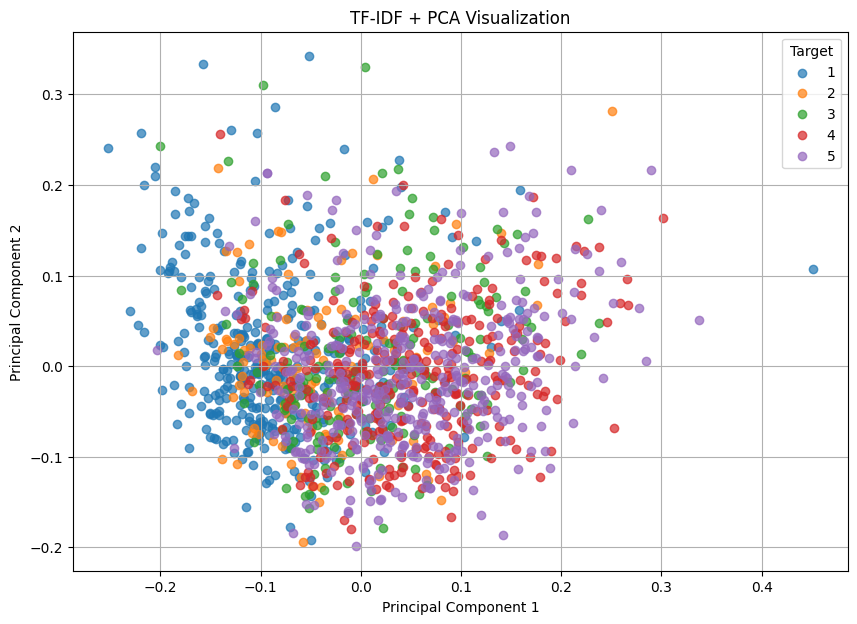

In [26]:
# Import libraries
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# -----------------------------
# 1. Select text and target
# -----------------------------
X_text = df["body"]
y = df["rating"]

# Encode target labels if they are strings
le = LabelEncoder()
y_encoded = le.fit_transform(y)


# -----------------------------
# 2. Convert text to TF-IDF vectors
# -----------------------------
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000,
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(X_text)

print("TF-IDF Shape:", X_tfidf.shape)


# -----------------------------
# 3. Apply PCA
# -----------------------------
# PCA requires dense matrix
X_dense = X_tfidf.toarray()

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_dense)

print("PCA Shape:", X_pca.shape)

print(
    "Explained Variance:",
    pca.explained_variance_ratio_,
    "Total:",
    sum(pca.explained_variance_ratio_)
)


# -----------------------------
# 4. Plot PCA visualization
# -----------------------------
plt.figure(figsize=(10,7))

for label in sorted(set(y_encoded)):
    idx = y_encoded == label
    
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=le.inverse_transform([label])[0],
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("TF-IDF + PCA Visualization")

plt.legend(title="Target")
plt.grid(True)

plt.show()